In [13]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2
from functions.processing import create_dataframe
DATA_PATH = "Data/"

# 🏥 **Identification of Invasive Ductal Carcinoma (IDC) in Biopsy Slides**  

## 📌 **Repository Objective**  
This repository aims to develop an approach to **identify invasive ductal carcinoma (IDC)** in breast cancer biopsy slide images using image processing techniques and machine learning.  

## 🩺 **What is IDC?**  
**Invasive Ductal Carcinoma (IDC)** is the most common type of breast cancer, accounting for **about 80% of invasive cases**. It originates in the **milk ducts**, the channels that transport milk from the mammary glands to the nipple.  

The term **"invasive"** means that the cancer has broken through the duct walls and spread to the **surrounding breast tissue**, potentially reaching the **lymph nodes** and even distant organs (**metastasis**).  

## 📊 **Dataset Structure and Distribution**  
The dataset used is available on Kaggle:  
🔗 [Breast Histopathology Images](https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images/data)  

### 🔹 **Organization**  
- The dataset is divided into **folders**, each corresponding to a **patient**.  
- Inside each folder, there are **cropped images** (_patches_) extracted from biopsy slides.  
- Each image is **50x50 pixels** and is **classified** as **IDC positive (1)** or **IDC negative (0)**.  

## 🖼️ **Image Format**  
Each image follows a standardized naming format:  

`u_xX_yY_classC.png`  

### 🔍 **Example Filename:**  

`10253_idx5_x1351_y1101_class0.png`  

### 📖 **Explanation:**  

| Element   | Meaning |
|-----------|---------|
| `10253_idx5` | **Patient ID** and scanned slide number |
| `x1351` | **X coordinate** of the cropped patch |
| `y1101` | **Y coordinate** of the cropped patch |
| `class0` | **Image class** (0 = IDC negative, 1 = IDC positive) |

This naming convention allows tracking the patch's origin within the original slide, facilitating the spatial analysis of cancerous cells.  

---  
✨ **With this repository, we aim to assist in breast cancer diagnosis, contributing to research and innovation in healthcare.**  


In [14]:
'''
!mkdir Data
!cd Data
!curl -L -o Data/breast-histopathology-images.zip\
!https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/breast-histopathology-images
!unzip breast-histopathology-images.zip
!rm breast-histopathology-images.zip
'''

'\n!mkdir Data\n!cd Data\n!curl -L -o Data/breast-histopathology-images.zip!https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/breast-histopathology-images\n!unzip breast-histopathology-images.zip\n!rm breast-histopathology-images.zip\n'

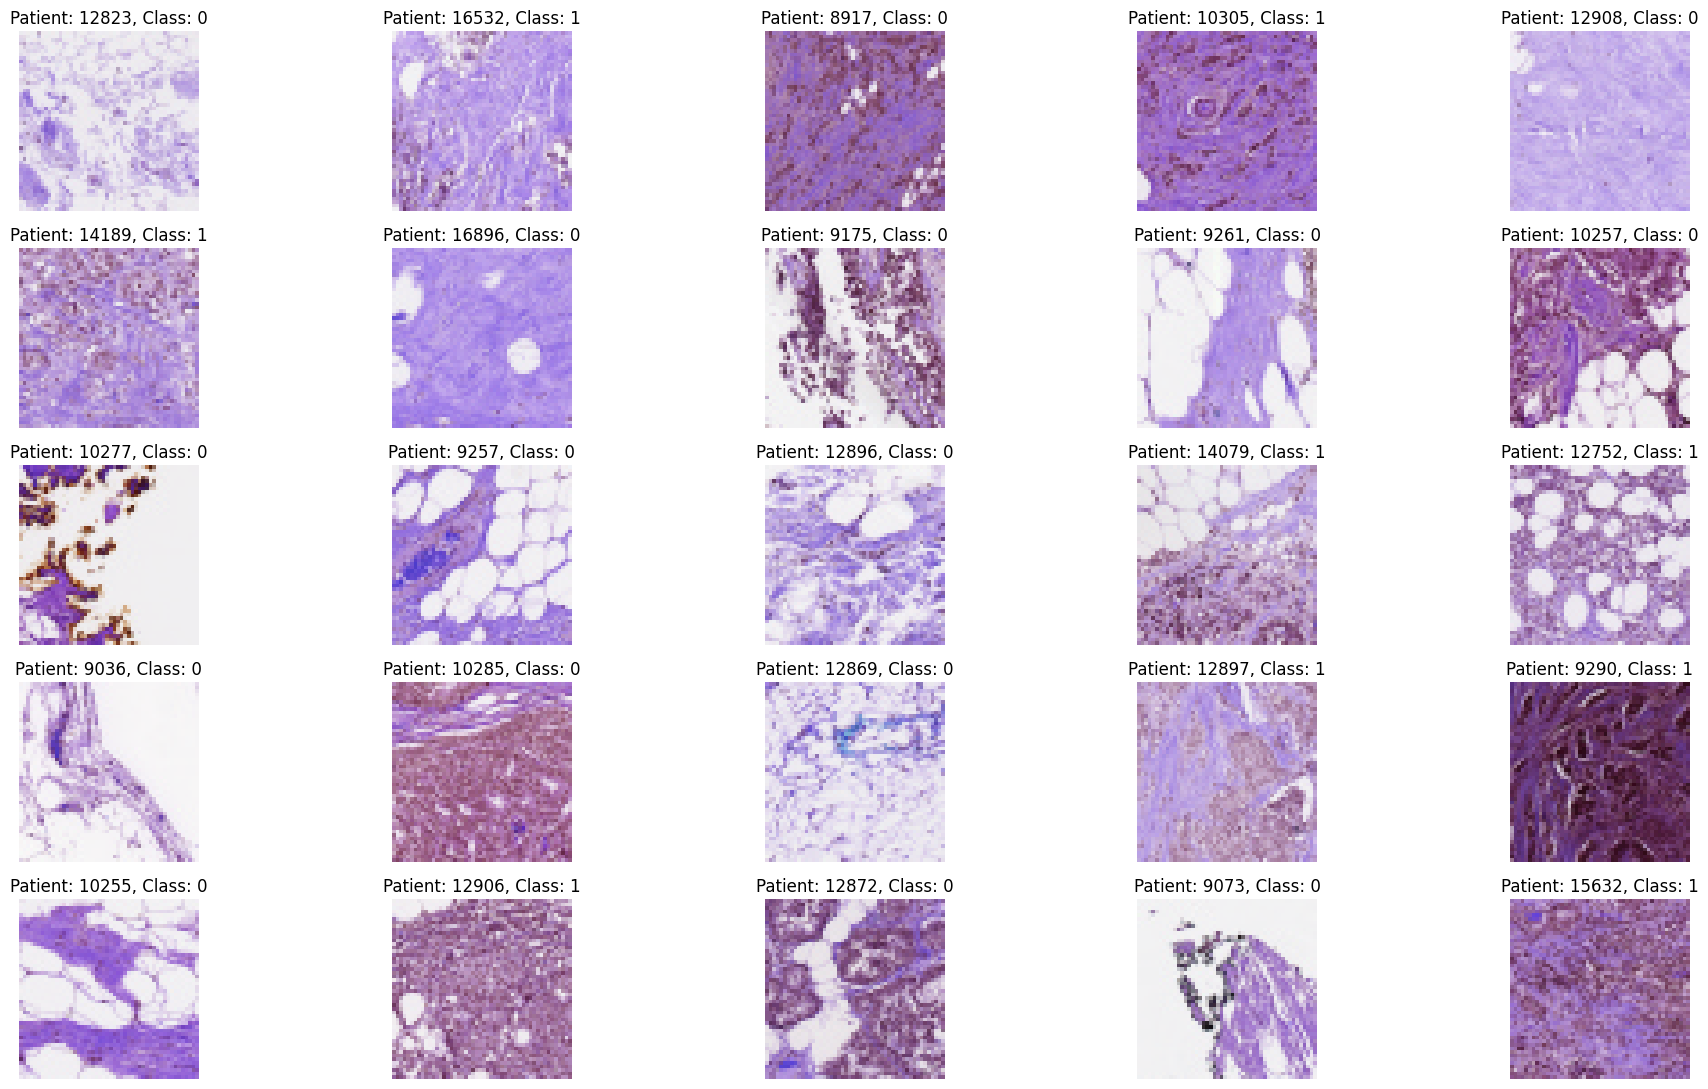

In [15]:
import random

PATIENT_ID = os.listdir(DATA_PATH)
num_images = 25  
fig, axes = plt.subplots(5, 5, figsize=(20, 11))  
axes = axes.flatten()  

for ax in axes:
    patient_id = random.choice(PATIENT_ID)
    class_label = random.choice(["0", "1"])
    image_file = random.choice(os.listdir(DATA_PATH + patient_id + "/" + class_label))
    image_path = os.path.join(DATA_PATH, patient_id, class_label, image_file)
    image = cv2.imread(image_path)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Patient: {patient_id}, Class: {class_label}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [16]:
df = create_dataframe(DATA_PATH)
df

,image_path,label
0,Data/12879/0/12879_idx5_x1451_y401_class0.png,0
1,Data/12879/0/12879_idx5_x1401_y901_class0.png,0
2,Data/12879/0/12879_idx5_x1901_y201_class0.png,0
3,Data/12879/0/12879_idx5_x1001_y951_class0.png,0
4,Data/12879/0/12879_idx5_x1801_y201_class0.png,0
...,...,...
277519,Data/12823/1/12823_idx5_x2801_y1051_class1.png,1
277520,Data/12823/1/12823_idx5_x3151_y1651_class1.png,1
277521,Data/12823/1/12823_idx5_x2951_y1001_class1.png,1
277522,Data/12823/1/12823_idx5_x3201_y951_class1.png,1
